# Lake Poopó - water surface extent (1985-2021) using Google earth engine

To capture a more comprenhensive, long-term record of the lake's shrinkage and any subsequent recovery, in this notebook, I extract and visualize the monthly water surface area from 1985 to 2022. For this extended tmeline, I  use satellite observations from the JRC Global Surface Water dataset, accessed via Google Earth Engine (GEE). 



In [7]:
import ee 
import pandas as pd
from pathlib import Path
from src.lakeclimate import jrc

import matplotlib.dates as mdates
import datetime as dt
import matplotlib.pyplot as plt 

ee.Authenticate()  # only needed once, then it remembers
ee.Initialize(project="lake-poopo-climate-2026")
path_root = Path.cwd()
# path to the extracted .csv water extent data
data_jrc_path = path_root / "data_jrc"

# Dataset

We first define the geographic area in which the Poopó lake and immediate sorrounding are contained (the rectangle captures the full extent of the lake at its historical maximum). The [dataset](https://developers.google.com/earth-engine/datasets/catalog/JRC_GSW1_4_MonthlyHistory) classifies each 30 meter pixel as water/non-water for every month from March 1984 to December 2021. 

In [8]:
# Coordinates for the bounds of a rectagle in which the Lake is contained.
# Google earth engine uses the format: (min_lon, min_lat, max_lon, max_lat) i.e. (West, South, East, North)
poopo_area = [-67.50, -19.20, -66.60,-18.30]
# Defines a rectangular geographic area within Earth engine
poopo_geom = ee.Geometry.Rectangle(list(poopo_area))

# ID of the dataset 
jrc_monthly = "JRC/GSW1_4/MonthlyHistory"


# Data download
The monthly water extent records are queried from GEE using the implemented function (`jrc.monthly_water_area_km2`) and cached locally as a .csv file. The resulting dataframe contains one row per month with water area and the valid-pixel coverage for the Lake Poopó bounding box.



In [9]:
lwe_jrc_path = data_jrc_path / "processed" / "Poopo_lwe_jrc_1985-2021.csv"

if lwe_jrc_path.exists():
    jrc_df = pd.read_csv(lwe_jrc_path, parse_dates=["date"])
    print(f"Loaded {len(jrc_df)} cached observations from {lwe_jrc_path}")
else:
    jrc_df = jrc.monthly_water_area_km2("1985-01-01", "2022-12-31")
    jrc_df.to_csv(lwe_jrc_path, index=False)
    print(f"Saved {len(jrc_df)} observations to {lwe_jrc_path}")

print(jrc_df.head())

Loaded 454 cached observations from /Users/nayualv/Desktop/Github_projects/Urus_project/Lake_Poopo/data_jrc/processed/Poopo_lwe_jrc_1985-2021.csv
        date  valid_area_km2  water_area_km2
0 1984-03-01        0.000000             0.0
1 1984-04-01        0.000000             0.0
2 1984-05-01        0.000000             0.0
3 1984-06-01       11.143252             0.0
4 1984-07-01        0.000000             0.0


# Data cleaning

Not every month has complete satellite coverage, due to clouds or data acquisition errors. To ensure that the water extent area values are reliable, we set a 80% valid pixel threshold.


In [10]:
path_root = Path.cwd()

jrc_df = pd.read_csv(lwe_jrc_path)
jrc_df["date"] = pd.to_datetime(jrc_df["date"])

total_area_km2 = jrc_df["valid_area_km2"].max()
#The percentage of the image box that has been observed
jrc_df["coverage"] = jrc_df["valid_area_km2"] / total_area_km2 * 100
# I require at least 80% coverage
clean_df = jrc_df[jrc_df["coverage"]>= 80].copy()
clean_df.to_csv("data_jrc/processed/Poopo_lwe_jrc_1985-2021_cleaned.csv", index=False)

# Visualization

The plot below shows the lake's monthly water surface area in km² over nearly four decades. 

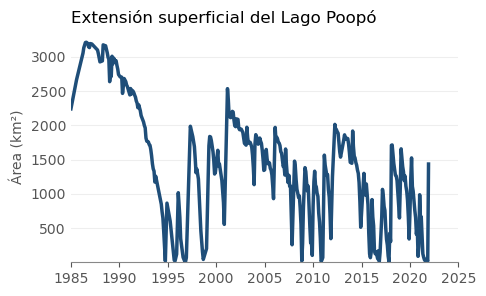

In [11]:

fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.plot(clean_df['date'], clean_df["water_area_km2"],linewidth =2.5, color="#1f4e79")
ax1.set_title("Extensión superficial del Lago Poopó",loc="left")
ax1.set_ylabel(f"Área (km²)",fontsize=10, fontweight="medium", color="#555")

ax1.set_xlim(dt.datetime(1985, 1, 1),dt.datetime(2025, 1, 1) )
ax1.tick_params(axis='both', labelsize=10)
ax1.tick_params(axis='y', length=0)
ax1.tick_params(colors="#555")
ax1.set_yticks([500, 1000, 1500, 2000,2500,3000])
ax1.set_ylim(bottom=0)

ax1.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.yaxis.grid(True, color="#eee", linewidth=0.8)
ax1.set_axisbelow(True)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_alpha(0)
ax1.spines["bottom"].set_color("#888")


path_to_save = path_root / "figures" / "Poopo_lwe_1984-2021.png"
plt.savefig(path_to_save, transparent = True,dpi=300, 
    bbox_inches="tight")
plt.show()

The JRC time series reveals a clear, long-term decline in Lake Poopó's surface area. Until the late 1980s, the lake had reached its highest recorded level, with a surface area of over 3000 km2. We can see that over the following years, the lake's surface area gradually decreased until 1994. Since then, the lake has recovered, but each time with an increasingly lower maximum surface area and for only shorter periods.

